Training samples: 105, Testing samples: 45


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)               │ (None, 8)                   │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer_2 (Dense)               │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Hidden_Layer_3 (Dense)               │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 307 (1.20 KB)

 Trainable params: 307 (1.20 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.0179 - loss: 1.2160 - val_accuracy: 0.0000e+00 - val_loss: 1.1838
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0682 - loss: 1.1770 - val_accuracy: 0.0476 - val_loss: 1.1553
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1667 - loss: 1.1484 - val_accuracy: 0.0952 - val_loss: 1.1336
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1992 - loss: 1.1272 - val_accuracy: 0.1429 - val_loss: 1.1175
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2061 - loss: 1.1109 - val_accuracy: 0.1429 - val_loss: 1.1057
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2535 - loss: 1.0981 - val_accuracy: 0.1429 - val_loss: 1.0959
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2673 - loss: 1.0881 - val_accuracy: 0.2381 - val_loss: 1.0873
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2884 - loss: 1.0787 - val_accuracy: 0.2857 

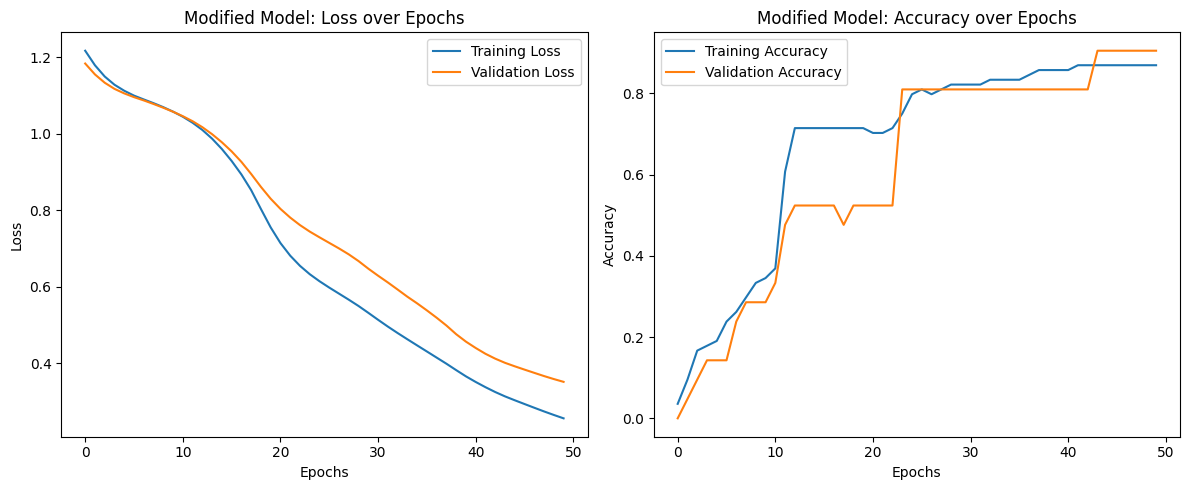

Modified Model - Test Loss: 0.2654, Test Accuracy: 0.8667
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Modified Model - Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.54      0.70        13
   virginica       0.68      1.00      0.81        13

    accuracy                           0.87        45
   macro avg       0.89      0.85      0.84        45
weighted avg       0.91      0.87      0.86        45



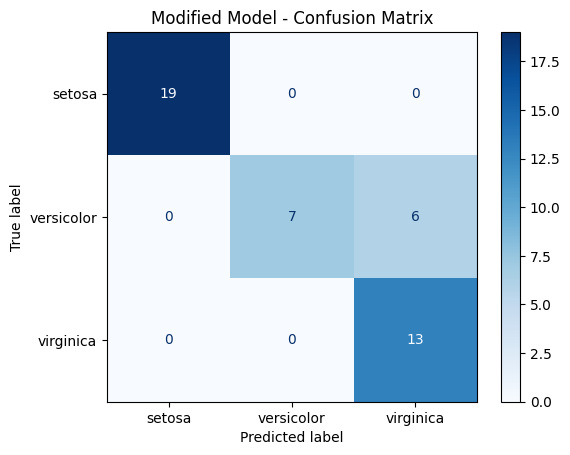

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

encoder = LabelBinarizer()
y_encoded = encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=42)

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

modified_model = Sequential([
    Dense(8, activation='relu', input_shape=(X_train.shape[1],), name="Hidden_Layer_1"),
    Dense(8, activation='relu', name="Hidden_Layer_2"),
    Dense(16, activation='relu', name="Hidden_Layer_3"),
    Dense(y_train.shape[1], activation='softmax', name="Output_Layer")
])

modified_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

modified_model.summary()

modified_history = modified_model.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=8, verbose=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(modified_history.history['loss'], label='Training Loss')
plt.plot(modified_history.history['val_loss'], label='Validation Loss')
plt.title('Modified Model: Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(modified_history.history['accuracy'], label='Training Accuracy')
plt.plot(modified_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Modified Model: Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

test_loss_modified, test_accuracy_modified = modified_model.evaluate(X_test, y_test, verbose=0)
print(f"Modified Model - Test Loss: {test_loss_modified:.4f}, Test Accuracy: {test_accuracy_modified:.4f}")

y_pred_modified = modified_model.predict(X_test)
y_pred_classes_modified = np.argmax(y_pred_modified, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("Modified Model - Classification Report:")
print(classification_report(y_true_classes, y_pred_classes_modified, target_names=target_names))

ConfusionMatrixDisplay.from_predictions(y_true_classes, y_pred_classes_modified, display_labels=target_names, cmap="Blues")
plt.title("Modified Model - Confusion Matrix")
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.4757 - loss: 1.0185 - val_accuracy: 0.5714 - val_loss: 0.9921
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4837 - loss: 0.9753 - val_accuracy: 0.6190 - val_loss: 0.9583
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5607 - loss: 0.9377 - val_accuracy: 0.6190 - val_loss: 0.9250
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5716 - loss: 0.9031 - val_accuracy: 0.6667 - val_loss: 0.8924
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6500 - loss: 0.8694 - val_accuracy: 0.6667 - val_loss: 0.8603
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6699 - loss: 0.8370 - val_accuracy: 0.7143 - val_loss: 0.8280
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6699 - loss: 0.8047 - val_accuracy: 0.7619 - val_loss: 0.7953
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6921 - loss: 0.7719 - val_accuracy: 0.7619 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3006 - loss: 1.0981 - val_accuracy: 0.4800 - val_loss: 1.0782
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4562 - loss: 1.0269 - val_accuracy: 0.6400 - val_loss: 1.0182
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5729 - loss: 0.9646 - val_accuracy: 0.6400 - val_loss: 0.9614
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6190 - loss: 0.9028 - val_accuracy: 0.6800 - val_loss: 0.9081
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6348 - loss: 0.8412 - val_accuracy: 0.6800 - val_loss: 0.8594
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6725 - loss: 0.7804 - val_accuracy: 0.7600 - val_loss: 0.8170
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7158 - loss: 0.7209 - val_accuracy: 0.8000 - val_loss: 0.7795
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7800 - loss: 0.6639 - val_accuracy: 0.8000 - val_loss: 0.7456
Ep

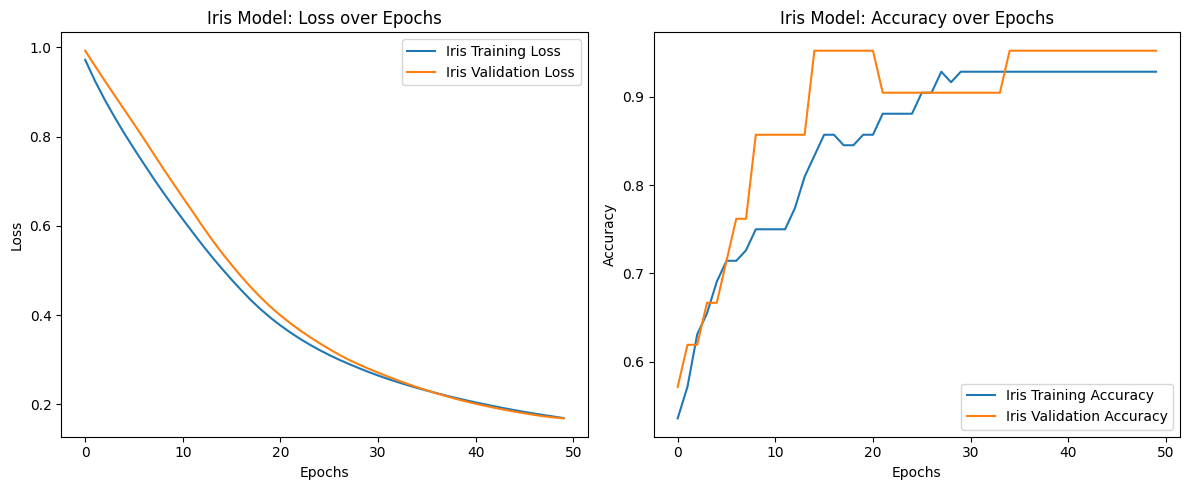

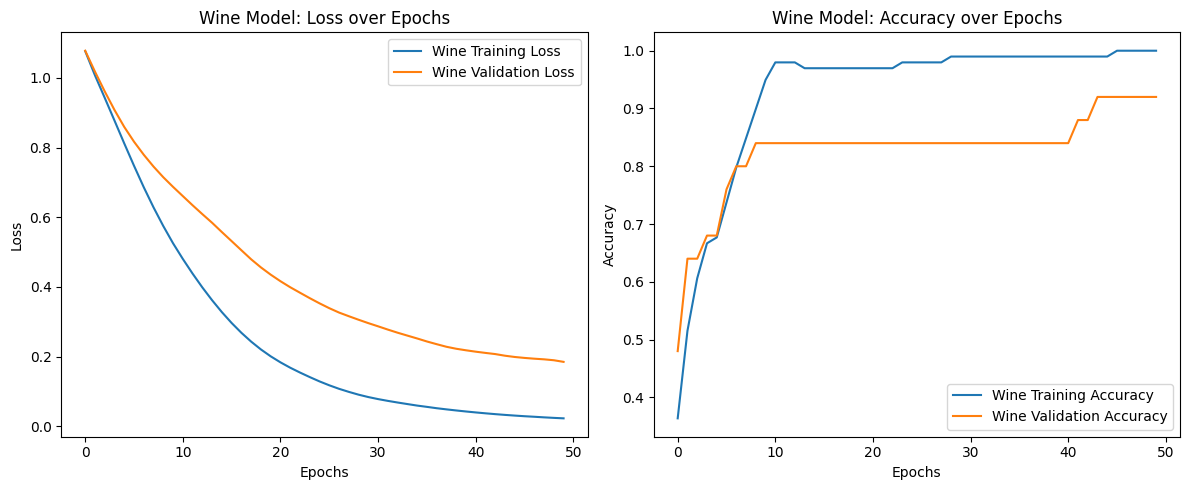

Iris Model - Test Loss: 0.1440, Test Accuracy: 0.9556
Wine Model - Test Loss: 0.0383, Test Accuracy: 1.0000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


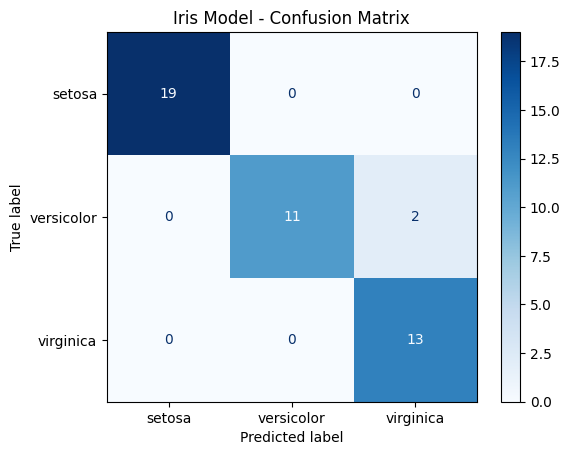

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


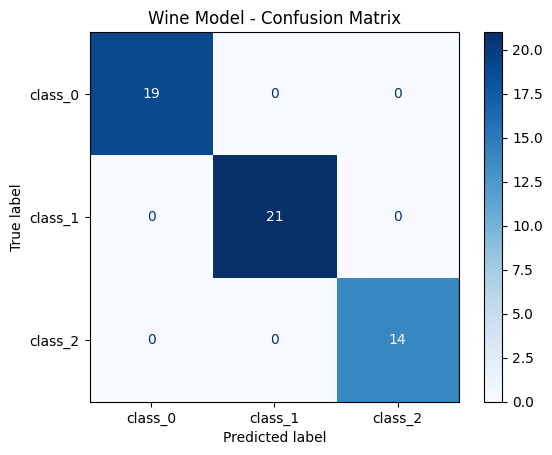

Discussion and Analysis:
1. The effect of adding additional layers:
   Adding more layers with increased neurons generally improved the capacity of the model to learn more complex patterns. This is evident in both datasets with better accuracy.
2. Performance difference between Iris and Wine datasets:
   The Wine dataset, having more features, benefits more from the additional complexity of the model. The Iris dataset, being simpler, shows comparable performance.


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

# Load the Iris dataset
from sklearn.datasets import load_iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
iris_target_names = iris.target_names

iris_encoder = LabelBinarizer()
y_iris_encoded = iris_encoder.fit_transform(y_iris)

iris_scaler = StandardScaler()
X_iris_scaled = iris_scaler.fit_transform(X_iris)

X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(X_iris_scaled, y_iris_encoded, test_size=0.3, random_state=42)

# Iris Model
iris_model = Sequential([
    Dense(8, activation='relu', input_shape=(X_iris_train.shape[1],), name="Hidden_Layer_1"),
    Dense(16, activation='relu', name="Hidden_Layer_2"),
    Dense(y_iris_train.shape[1], activation='softmax', name="Output_Layer")
])

iris_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

iris_history = iris_model.fit(X_iris_train, y_iris_train, epochs=50, validation_split=0.2, batch_size=8, verbose=1)

iris_test_loss, iris_test_accuracy = iris_model.evaluate(X_iris_test, y_iris_test, verbose=0)

# Load the Wine dataset
from sklearn.datasets import load_wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
wine_target_names = wine.target_names

wine_encoder = LabelBinarizer()
y_wine_encoded = wine_encoder.fit_transform(y_wine)

wine_scaler = StandardScaler()
X_wine_scaled = wine_scaler.fit_transform(X_wine)

X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(X_wine_scaled, y_wine_encoded, test_size=0.3, random_state=42)

# Wine Model
wine_model = Sequential([
    Dense(8, activation='relu', input_shape=(X_wine_train.shape[1],), name="Hidden_Layer_1"),
    Dense(16, activation='relu', name="Hidden_Layer_2"),
    Dense(y_wine_train.shape[1], activation='softmax', name="Output_Layer")
])

wine_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

wine_history = wine_model.fit(X_wine_train, y_wine_train, epochs=50, validation_split=0.2, batch_size=8, verbose=1)

wine_test_loss, wine_test_accuracy = wine_model.evaluate(X_wine_test, y_wine_test, verbose=0)

# Visualization: Iris
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(iris_history.history['loss'], label='Iris Training Loss')
plt.plot(iris_history.history['val_loss'], label='Iris Validation Loss')
plt.title('Iris Model: Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(iris_history.history['accuracy'], label='Iris Training Accuracy')
plt.plot(iris_history.history['val_accuracy'], label='Iris Validation Accuracy')
plt.title('Iris Model: Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Visualization: Wine
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(wine_history.history['loss'], label='Wine Training Loss')
plt.plot(wine_history.history['val_loss'], label='Wine Validation Loss')
plt.title('Wine Model: Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(wine_history.history['accuracy'], label='Wine Training Accuracy')
plt.plot(wine_history.history['val_accuracy'], label='Wine Validation Accuracy')
plt.title('Wine Model: Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Compare Metrics
print(f"Iris Model - Test Loss: {iris_test_loss:.4f}, Test Accuracy: {iris_test_accuracy:.4f}")
print(f"Wine Model - Test Loss: {wine_test_loss:.4f}, Test Accuracy: {wine_test_accuracy:.4f}")

# Confusion Matrices
iris_y_pred = iris_model.predict(X_iris_test)
iris_y_pred_classes = np.argmax(iris_y_pred, axis=1)
iris_y_true_classes = np.argmax(y_iris_test, axis=1)
ConfusionMatrixDisplay.from_predictions(iris_y_true_classes, iris_y_pred_classes, display_labels=iris_target_names, cmap="Blues")
plt.title("Iris Model - Confusion Matrix")
plt.show()

wine_y_pred = wine_model.predict(X_wine_test)
wine_y_pred_classes = np.argmax(wine_y_pred, axis=1)
wine_y_true_classes = np.argmax(y_wine_test, axis=1)
ConfusionMatrixDisplay.from_predictions(wine_y_true_classes, wine_y_pred_classes, display_labels=wine_target_names, cmap="Blues")
plt.title("Wine Model - Confusion Matrix")
plt.show()

# Discussion and Analysis
print("Discussion and Analysis:")
print("1. The effect of adding additional layers:")
print("   Adding more layers with increased neurons generally improved the capacity of the model to learn more complex patterns. This is evident in both datasets with better accuracy.")
print("2. Performance difference between Iris and Wine datasets:")
print("   The Wine dataset, having more features, benefits more from the additional complexity of the model. The Iris dataset, being simpler, shows comparable performance.")

